In [ ]:
# # Install the necessary packages
# %pip install polars
# %pip install youtube-transcript-api
# %pip install google-api-python-client



### Data engeneering para obtener data de YouTube


Basado en el [Shawhin T](https://github.com/ShawhinT/YouTube-Blog/blob/main/full-stack-data-science/data-engineering/1_pull-vid-ids.ipynb)



In [13]:
# Librerias
from googleapiclient.discovery import build
import polars as pl
import requests
import json
import os 
import time 


**Obtener Channel-ID**

In [2]:
def get_videos(response: requests.models.Response) -> list:
    """Get youtube video data from get request response, function by Shawhin"""

    video_record_list = []
    
    for raw_item in json.loads(response.text)['items']:
    
        # only execute for youtube videos
        if raw_item['id']['kind'] != "youtube#video":
            continue
        
        video_record = {}
        video_record['video_id'] = raw_item['id']['videoId']
        video_record['datetime'] = raw_item['snippet']['publishedAt']
        video_record['title'] = raw_item['snippet']['title']
        
        video_record_list.append(video_record)

    return video_record_list


def obtener_channel_id(channel_name, api_key):
    """
    Función para buscar el Channel ID de un canal dado su nombre.
    """
    youtube = build('youtube', 'v3', developerKey=api_key)
    
    # Realiza una búsqueda del canal por su nombre
    request = youtube.search().list(
        part="snippet",
        q=channel_name,
        type="channel",
        maxResults=1  # Obtenemos solo el primer resultado
    )
    
    response = request.execute()
    if response['items']:
        channel_id = response['items'][0]['snippet']['channelId']
        return channel_id
    else:
        return None


Previamnete genera una API_KEY utilizando google cloud console. 

In [4]:
with open("key.json", "r") as config_file:
    config = json.load(config_file)

API_KEY = config.get("API_KEY")


In [5]:
# Clave de API de Google 
CHANNEL_NAME = 'ElFedeWolf' #El fewdelobo Lol :) 


channel_id = obtener_channel_id(CHANNEL_NAME, API_KEY)
if channel_id:
    print(f"Channel ID para '{CHANNEL_NAME}': {channel_id}")
else:
    print(f"Non response.")


Channel ID para 'ElFedeWolf': UCWI2X2x3KASrvEZXdBVNxkA


In [20]:
CHANNEL_NAME_3B1B = '3blue1brown'

chennel_id_3B1B = obtener_channel_id(CHANNEL_NAME_3B1B, API_KEY)
if chennel_id_3B1B: 
    print(f"Channel ID para '{CHANNEL_NAME_3B1B}': {channel_id}")
else:
    print("Non response.")

Channel ID para '3blue1brown': UCWI2X2x3KASrvEZXdBVNxkA


In [6]:
url = 'https://www.googleapis.com/youtube/v3/search'

# initialize page token
page_token = None
video_record_list = []

In [17]:
page_token = None
video_record_list_3B1B = []

In [18]:
%%time
# extract video data across multiple search result pages
while page_token != 0:
    # define parameters for API call
    params = {'key': API_KEY, 'channelId': channel_id, 
              'part': ["snippet","id"], 'order': "date", 
              'maxResults':50, 'pageToken': page_token}
    
    # make get request
    response = requests.get(url, params=params)

    # append video records to list
    video_record_list_3B1B += get_videos(response)

    try:
        # grab next page token
        page_token = json.loads(response.text)['nextPageToken']
    except:
        # if no next page token kill while loop
        page_token = 0

CPU times: total: 31.2 ms
Wall time: 2.78 s


In [19]:
video_record_list_3B1B

[{'video_id': 'KdphJz9UqJM',
  'datetime': '2025-05-10T01:36:45Z',
  'title': 'Karate Kid : La Saga en 1 Video'},
 {'video_id': 'BfHj76TbNTE',
  'datetime': '2025-05-07T02:20:49Z',
  'title': 'Las 5 Mejores Series de Marvel I Fedewolf'},
 {'video_id': 'UBnD4wa0EMM',
  'datetime': '2025-05-03T22:44:03Z',
  'title': 'Beetlejuice 2 : La Historia en 1 Video'},
 {'video_id': 'zdB0GVDl-Ag',
  'datetime': '2025-04-24T20:46:24Z',
  'title': 'TERRIFIER 3 : La Historia en 1 Video'},
 {'video_id': '8XdOPGAWHto',
  'datetime': '2025-04-19T23:49:55Z',
  'title': 'Dragon Ball Z : La Saga de Cooler (El hermano de Freezer que NO es Canon)'},
 {'video_id': 'QrhWqr4aN_s',
  'datetime': '2025-04-15T02:53:41Z',
  'title': 'MENTIRAS VERDADERAS : La Historia en 1 Video'},
 {'video_id': 'uAT4BK2msjk',
  'datetime': '2025-04-08T18:46:31Z',
  'title': 'WALL•E : La Historia en 1 Video'},
 {'video_id': 'CaQ3OMfbeZo',
  'datetime': '2025-03-31T01:33:14Z',
  'title': 'Una Pareja Explosiva : La Saga en 1 Video'},
 

In [7]:
%%time
# extract video data across multiple search result pages
while page_token != 0:
    # define parameters for API call
    params = {'key': API_KEY, 'channelId': channel_id, 
              'part': ["snippet","id"], 'order': "date", 
              'maxResults':50, 'pageToken': page_token}
    
    # make get request
    response = requests.get(url, params=params)

    # append video records to list
    video_record_list += get_videos(response)

    try:
        # grab next page token
        page_token = json.loads(response.text)['nextPageToken']
    except:
        # if no next page token kill while loop
        page_token = 0

CPU times: total: 31.2 ms
Wall time: 2.74 s


In [15]:
from datetime import datetime
video_list_record_sorted = sorted(video_record_list, key= lambda x: datetime.strptime(x['datetime'], "%Y-%m-%dT%H:%M:%SZ"), reverse=True)
print(video_list_record_sorted[0:5]) 
# video_record_list

[{'video_id': 'KdphJz9UqJM', 'datetime': '2025-05-10T01:36:45Z', 'title': 'Karate Kid : La Saga en 1 Video'}, {'video_id': 'BfHj76TbNTE', 'datetime': '2025-05-07T02:20:49Z', 'title': 'Las 5 Mejores Series de Marvel I Fedewolf'}, {'video_id': 'UBnD4wa0EMM', 'datetime': '2025-05-03T22:44:03Z', 'title': 'Beetlejuice 2 : La Historia en 1 Video'}, {'video_id': 'zdB0GVDl-Ag', 'datetime': '2025-04-24T20:46:24Z', 'title': 'TERRIFIER 3 : La Historia en 1 Video'}, {'video_id': '8XdOPGAWHto', 'datetime': '2025-04-19T23:49:55Z', 'title': 'Dragon Ball Z : La Saga de Cooler (El hermano de Freezer que NO es Canon)'}]


In [9]:
data_folder = 'data'
if not os.path.exists(data_folder):
    os.makedirs(data_folder)

pl.DataFrame(video_record_list).write_parquet(os.path.join(data_folder, 'video-ids.parquet'))
pl.DataFrame(video_record_list).write_csv(os.path.join(data_folder, 'video-ids.csv'))

In [20]:
df = pl.DataFrame(video_record_list)
print(df.head())

shape: (5, 3)
┌─────────────┬──────────────────────┬───────────────────────────────────┐
│ video_id    ┆ datetime             ┆ title                             │
│ ---         ┆ ---                  ┆ ---                               │
│ str         ┆ str                  ┆ str                               │
╞═════════════╪══════════════════════╪═══════════════════════════════════╡
│ I0Tv1eF7EWs ┆ 2024-12-10T20:00:08Z ┆ LA SUSTANCIA: La Historia en 1 V… │
│ IL5jNFMBoMk ┆ 2024-12-03T23:16:50Z ┆ ARCANE (Temporada 1) La Historia… │
│ ws7B6-odAiA ┆ 2024-11-14T19:45:02Z ┆ Deadpool &amp; Wolverine : La Hi… │
│ 65L8TwOMiL8 ┆ 2024-10-29T21:00:04Z ┆ Terrifier (La 1, la 2 y el Orige… │
│ 6yxIG_QUYxs ┆ 2024-10-15T19:00:03Z ┆ Silent Hill 1 y 2 : La Historia … │
└─────────────┴──────────────────────┴───────────────────────────────────┘


Get the transcripts from the videos

In [ ]:
from youtube_transcript_api import YouTubeTranscriptApi, TranscriptsDisabled, VideoUnavailable, NoTranscriptFound

# Random video ID
video_id = "IL5jNFMBoMk"

try:
    # Listar las transcripciones disponibles
    transcript_list = YouTubeTranscriptApi.list_transcripts(video_id)
    
    print("Idiomas disponibles para transcripciones:")
    for transcript in transcript_list:
        print(f"- {transcript.language} (código: {transcript.language_code})")

except TranscriptsDisabled:
    print(f"Las transcripciones están deshabilitadas para el video {video_id}")
except VideoUnavailable:
    print(f"El video no está disponible: {video_id}")
except Exception as e:
    print(f"Error inesperado: {e}")


Idiomas disponibles para transcripciones:
- Spanish (auto-generated) (código: es)


Utilice el codigo para extraer las conferencias en espanol que me sugeriste, como lo  modifico si tengo un dataframe de polars como el que adjunto en el cual la primera columna son los ids de los videos, guarda transcript_text en una lista donde 

In [ ]:
video_id = "IL5jNFMBoMk"

try:
    # Obtener la transcripción en español (auto-generada)
    transcript = YouTubeTranscriptApi.get_transcript(video_id, languages=['es'])
    
    # Combinar los fragmentos de texto
    transcript_text = " ".join([item['text'] for item in transcript])
    print("Transcripción en español, primeros 500 tokens:\n")
    print(transcript_text[0:500])
except NoTranscriptFound:
    print("No se encontró una transcripción en el idioma solicitado.")
except TranscriptsDisabled:
    print("Las transcripciones están deshabilitadas para este video.")
except VideoUnavailable:
    print("El video no está disponible.")


Transcripción en español, primeros 500 tokens:

qué tal gente Sean bienvenidos a un nuevo video en el Canal del Fed Wolf hace un par de semanas Ya se estrenó la segunda temporada de arcin en Netflix y semana con semana va saliendo un nuevo episodio de la segunda temporada es por eso que si quieres entrarle a la segunda temporada de esta bonita serie el día de hoy vamos a armar un resumen de toda la primera temporada para que entres Sabiendo y recordándolo todo que comience el video por favor hermanito puch Play Había una vez dos hermanitas ll


In [27]:
# Reload the data
df = pl.read_parquet('data/video-ids.parquet')
print(df.head())

shape: (5, 3)
┌─────────────┬──────────────────────┬───────────────────────────────────┐
│ video_id    ┆ datetime             ┆ title                             │
│ ---         ┆ ---                  ┆ ---                               │
│ str         ┆ str                  ┆ str                               │
╞═════════════╪══════════════════════╪═══════════════════════════════════╡
│ I0Tv1eF7EWs ┆ 2024-12-10T20:00:08Z ┆ LA SUSTANCIA: La Historia en 1 V… │
│ IL5jNFMBoMk ┆ 2024-12-03T23:16:50Z ┆ ARCANE (Temporada 1) La Historia… │
│ ws7B6-odAiA ┆ 2024-11-14T19:45:02Z ┆ Deadpool &amp; Wolverine : La Hi… │
│ 65L8TwOMiL8 ┆ 2024-10-29T21:00:04Z ┆ Terrifier (La 1, la 2 y el Orige… │
│ 6yxIG_QUYxs ┆ 2024-10-15T19:00:03Z ┆ Silent Hill 1 y 2 : La Historia … │
└─────────────┴──────────────────────┴───────────────────────────────────┘


Obtener todas las trasncripciones

In [28]:
transcript_text_list = []

for i in range(len(df)):
    video_id = df["video_id"][i]  
    try:
        # Obtener la transcripción en español (auto-generada)
        transcript = YouTubeTranscriptApi.get_transcript(video_id, languages=['es'])
        
        # Combinar los fragmentos de texto
        transcript_text = " ".join([item['text'] for item in transcript])
        print(f"Transcripción extraída para el video {video_id}")
    except NoTranscriptFound:
        transcript_text = "No se encontró una transcripción en español."
        print(f"Error: {transcript_text} para el video {video_id}")
    except TranscriptsDisabled:
        transcript_text = "Las transcripciones están deshabilitadas para este video."
        print(f"Error: {transcript_text} para el video {video_id}")
    except VideoUnavailable:
        transcript_text = "El video no está disponible."
        print(f"Error: {transcript_text} para el video {video_id}")
    except Exception as e:
        transcript_text = f"Error inesperado: {e}"
        print(f"Error inesperado para el video {video_id}: {e}")
    
    # Añadir la transcripción (o mensaje de error) a la lista
    transcript_text_list.append(transcript_text)
    
    # Esperar 1 segundo entre solicitudes
    time.sleep(1)

# Crear un nuevo DataFrame con la columna de transcripciones
df = df.with_columns(pl.Series("transcript", transcript_text_list))


Transcripción extraída para el video I0Tv1eF7EWs
Transcripción extraída para el video IL5jNFMBoMk
Transcripción extraída para el video ws7B6-odAiA
Transcripción extraída para el video 65L8TwOMiL8
Transcripción extraída para el video 6yxIG_QUYxs
Transcripción extraída para el video hRnKW9tU1L8
Transcripción extraída para el video REgaws8m5Es
Transcripción extraída para el video FtyBNOoLhcY
Transcripción extraída para el video r1fS8BLi__g
Transcripción extraída para el video rvrBec5nT0g
Transcripción extraída para el video MthFZkjvlR4
Transcripción extraída para el video VeeDYucuby0
Transcripción extraída para el video WtND_gu3awM
Transcripción extraída para el video wAwwDdRgDrg
Transcripción extraída para el video 20rkPu2K7wo
Transcripción extraída para el video KNDH3a7aTfs
Transcripción extraída para el video BgjDmxfjgK4
Transcripción extraída para el video yc_uaLdmiPY
Transcripción extraída para el video wLtAJEOwzB4
Transcripción extraída para el video 4WzxR5FTEf0
Transcripción extraí

In [39]:
print(df.head())

shape: (5, 4)
┌─────────────┬──────────────────────┬───────────────────────────────────┬────────────────────┐
│ video_id    ┆ datetime             ┆ title                             ┆ transcript         │
│ ---         ┆ ---                  ┆ ---                               ┆ ---                │
│ str         ┆ str                  ┆ str                               ┆ str                │
╞═════════════╪══════════════════════╪═══════════════════════════════════╪════════════════════╡
│ I0Tv1eF7EWs ┆ 2024-12-10T20:00:08Z ┆ LA SUSTANCIA: La Historia en 1 V… ┆ qué tal gente Sean │
│             ┆                      ┆                                   ┆ bienvenidos a…     │
│ IL5jNFMBoMk ┆ 2024-12-03T23:16:50Z ┆ ARCANE (Temporada 1) La Historia… ┆ qué tal gente Sean │
│             ┆                      ┆                                   ┆ bienvenidos a…     │
│ ws7B6-odAiA ┆ 2024-11-14T19:45:02Z ┆ Deadpool &amp; Wolverine : La Hi… ┆ qué tal gente Sean │
│             ┆           

In [40]:
# write data to file
df.write_parquet('data/video-transcripts.parquet')
df.write_csv('data/video-transcripts.csv')

Analisis exploratorio

In [3]:
df = pl.read_parquet('data/video-transcripts.parquet')

print("shape:", df.shape)
print("n unique rows:", df.n_unique())
for j in range(df.shape[1]):
    print("n unique elements (" + df.columns[j] + "):", df[:,j].n_unique())

shape: (371, 4)
n unique rows: 371
n unique elements (video_id): 371
n unique elements (datetime): 371
n unique elements (title): 371
n unique elements (transcript): 346


In [6]:
print(df.head())

shape: (5, 4)
┌─────────────┬──────────────────────┬───────────────────────────────────┬────────────────────┐
│ video_id    ┆ datetime             ┆ title                             ┆ transcript         │
│ ---         ┆ ---                  ┆ ---                               ┆ ---                │
│ str         ┆ str                  ┆ str                               ┆ str                │
╞═════════════╪══════════════════════╪═══════════════════════════════════╪════════════════════╡
│ I0Tv1eF7EWs ┆ 2024-12-10T20:00:08Z ┆ LA SUSTANCIA: La Historia en 1 V… ┆ qué tal gente Sean │
│             ┆                      ┆                                   ┆ bienvenidos a…     │
│ IL5jNFMBoMk ┆ 2024-12-03T23:16:50Z ┆ ARCANE (Temporada 1) La Historia… ┆ qué tal gente Sean │
│             ┆                      ┆                                   ┆ bienvenidos a…     │
│ ws7B6-odAiA ┆ 2024-11-14T19:45:02Z ┆ Deadpool &amp; Wolverine : La Hi… ┆ qué tal gente Sean │
│             ┆           

In [7]:
print("Total number of title characters:", sum(len(df['title'][i]) for i in range(len(df))))
print("Total number of transcript characters:", sum(len(df['transcript'][i]) for i in range(len(df))))

Total number of title characters: 16284
Total number of transcript characters: 4672889


In [ ]:
import matplotlib.pyplot as plt

df = df.with_columns(
    pl.col("datetime").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%SZ").alias("datetime_parsed")
)

C:\Users\ericl\AppData\Local\Temp\ipykernel_31504\1967732933.py:4: DeprecationWarning: `groupby_dynamic` is deprecated. It has been renamed to `group_by_dynamic`.
  monthly_counts = df.groupby_dynamic("datetime_parsed", every="1mo").agg([
C:\Users\ericl\AppData\Local\Temp\ipykernel_31504\1967732933.py:4: DeprecationWarning: `truncate` is deprecated and will be removed in a future version. Please replace `truncate=True` with `label='left'` to silence this warning.
  monthly_counts = df.groupby_dynamic("datetime_parsed", every="1mo").agg([


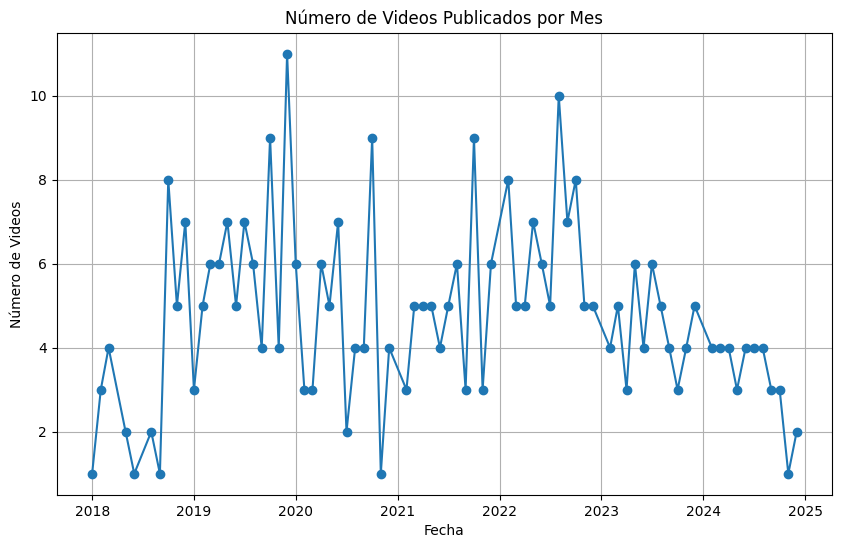

In [11]:
df = df.sort("datetime_parsed")

# Agrupar por mes y contar publicaciones
monthly_counts = df.groupby_dynamic("datetime_parsed", every="1mo").agg([
    pl.count("video_id").alias("count")
])

monthly_counts = monthly_counts.to_pandas()

plt.figure(figsize=(10, 6))
plt.plot(monthly_counts["datetime_parsed"], monthly_counts["count"], marker='o')
plt.title("Número de Videos Publicados por Mes")
plt.xlabel("Fecha")
plt.ylabel("Número de Videos")
plt.grid()
plt.show()

In [12]:
print(df.head())

shape: (5, 5)
┌─────────────┬──────────────────────┬─────────────────────┬─────────────────────┬─────────────────┐
│ video_id    ┆ datetime             ┆ title               ┆ transcript          ┆ datetime_parsed │
│ ---         ┆ ---                  ┆ ---                 ┆ ---                 ┆ ---             │
│ str         ┆ str                  ┆ str                 ┆ str                 ┆ datetime[μs]    │
╞═════════════╪══════════════════════╪═════════════════════╪═════════════════════╪═════════════════╡
│ zDiFefDiEIg ┆ 2018-01-24T02:56:22Z ┆ 5 Cosas que no      ┆ qué tal gente sean  ┆ 2018-01-24      │
│             ┆                      ┆ debes hacer cuand…  ┆ bienvenidos a…      ┆ 02:56:22        │
│ KWjECbL01Zc ┆ 2018-02-10T04:18:26Z ┆ Las mamás tienen    ┆ hola amigos buenas  ┆ 2018-02-10      │
│             ┆                      ┆ poderes...          ┆ tardes a lo l…      ┆ 04:18:26        │
│ mfEQiz08olg ┆ 2018-02-13T02:30:01Z ┆ 5 Cosas que hemos   ┆ detergente sean 

Guardar transformed data 

In [ ]:
df.write_parquet('data/video-transcripts.parquet')
df.write_csv('data/video-transcripts.csv')